# 01 · Tendencia estructural, valuación y expectativas incorporadas

**Objetivo / Goal.** Convertir preguntas cualitativas del ciclo en diagnósticos reproducibles: tendencia estructural de largo plazo, tendencia estructural promedio, desviación logarítmica del precio, valuación relativa, expectativas incorporadas y episodios de *extreme undervaluation → normalization*.

Esto es una formalización independiente inspirada en conceptos públicos asociados con Maru Cape y Howard Marks; **no reproduce ni afirma conocer una metodología propietaria**. Los resultados son investigación descriptiva, no señales operativas ni asesoramiento financiero. El notebook no modifica la preregistración de `CYCLE-ASYMMETRY-001`.

## Fuente y modo de ejecución / Source and execution mode

`DATA_MODE='synthetic'` usa una demostración determinística. Los modos `auto` y `cycle1` se rechazan antes de leer archivos históricos; el adaptador real requiere una futura configuración explícita de fuentes y particiones.

Los ejemplos iniciales ilustran cálculos sobre series sintéticas. El Workbench al final usa otros escenarios con scores ingresados a mano y los identifica por separado. Ninguno representa una evaluación actual del mercado.


In [2]:
from dataclasses import asdict, is_dataclass
from datetime import date
from pathlib import Path
import hashlib
import json
import math
import warnings
import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    plt = None
    HAS_MATPLOTLIB = False

try:
    from spy_predictor_quant import cycle_analysis_tools as cycle_tools
except ImportError:
    cycle_tools = None

DATA_MODE = 'synthetic'  # Secondary workbench currently supports synthetic inputs only.
if DATA_MODE != 'synthetic':
    raise ValueError('Real-data notebook access is closed pending the secondary manifest adapter.')
INSTRUMENT = 'SPY'       # SPY or QQQ when Cycle 1 artifacts exist
SYNTHETIC_SEED = 20260906
TREND_WINDOWS = (60, 84, 120)

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'config' / 'cycle1.json').exists():
            return candidate
    raise FileNotFoundError('Repository root with config/cycle1.json not found')

REPO_ROOT = find_repo_root()

def read_ndjson(path):
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]

def verify_sha256(path, expected):
    actual = hashlib.sha256(path.read_bytes()).hexdigest()
    if actual != expected:
        raise ValueError(f'Hash mismatch for {path}: {actual} != {expected}')

def month_labels(count, start_year=2000, start_month=1):
    labels = []
    for offset in range(count):
        ordinal = start_year * 12 + start_month - 1 + offset
        labels.append(f'{ordinal // 12:04d}-{ordinal % 12 + 1:02d}')
    return np.asarray(labels)

def synthetic_bundle():
    rng = np.random.default_rng(SYNTHETIC_SEED)
    n = 288
    t = np.arange(n, dtype=float)
    log_fundamental = 4.45 + 0.0032 * t + 0.055 * np.sin(2*np.pi*t/108)
    sentiment = 0.20*np.sin(2*np.pi*(t-16)/82) + 0.055*np.sin(2*np.pi*t/27)
    sentiment -= 0.32*np.exp(-0.5*((t-106)/7)**2)
    sentiment -= 0.25*np.exp(-0.5*((t-226)/6)**2)
    log_price = log_fundamental + sentiment + rng.normal(0, 0.013, n)
    return {
        'dates': month_labels(n), 'price': np.exp(log_price),
        'fundamental_proxy': np.exp(log_fundamental),
        'cycle1_valuation_score': np.full(n, np.nan),
        'state': np.asarray(['SYNTHETIC'] * n),
        'meta': {'source': 'deterministic-synthetic', 'seed': SYNTHETIC_SEED,
                 'evidenceTier': 'DEMONSTRATION_ONLY', 'manifest': None}
    }

def newest_track_manifest(instrument):
    candidates = []
    pattern = f'datasets/cycle1/cycle1-monthly-*/validation-{instrument.lower()}/manifest.json'
    for track_path in REPO_ROOT.glob(pattern):
        dataset_manifest = track_path.parents[1] / 'manifest.json'
        if dataset_manifest.exists():
            root = json.loads(dataset_manifest.read_text(encoding='utf-8'))
            candidates.append((root.get('asOfDate', ''), track_path.as_posix(), track_path))
    return max(candidates)[2] if candidates else None

def cycle1_bundle(instrument):
    manifest_path = newest_track_manifest(instrument)
    if manifest_path is None:
        raise FileNotFoundError(f'No Cycle 1 validation manifest for {instrument}')
    root_manifest = json.loads((manifest_path.parents[1] / 'manifest.json').read_text(encoding='utf-8'))
    track_entry = next(item for item in root_manifest['tracks'] if item['instrument'] == instrument)
    verify_sha256(manifest_path, track_entry['manifestSha256'])
    manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
    artifacts = {item['kind']: item for item in manifest['normalizedArtifacts']}
    for item in artifacts.values():
        verify_sha256(REPO_ROOT / item['path'], item['sha256'])
    daily = read_ndjson(REPO_ROOT / artifacts['total-return-index']['path'])
    states = read_ndjson(REPO_ROOT / artifacts['features-and-states']['path'])
    last_by_month = {}
    for row in daily:
        key = row['sessionDate'][:7]
        if key not in last_by_month or row['sessionDate'] > last_by_month[key]['sessionDate']:
            last_by_month[key] = row
    ordered = [last_by_month[key] for key in sorted(last_by_month)]
    by_month = {row['snapshotDate'][:7]: row for row in states}
    dates = np.asarray([row['sessionDate'][:7] for row in ordered])
    price = np.asarray([float(row['totalReturnIndex']) for row in ordered])
    valuation = np.asarray([
        float(by_month[d]['dimensionScores']['valuation']) if d in by_month else np.nan for d in dates
    ])
    labels = np.asarray([by_month[d]['state'] if d in by_month else 'WARMUP' for d in dates])
    # Cycle 1 has no forward-fundamentals level. The trend is an explicitly labeled proxy.
    return {'dates': dates, 'price': price, 'fundamental_proxy': None,
            'cycle1_valuation_score': valuation, 'state': labels,
            'meta': {'source': 'cycle1-verified-artifacts',
                     'evidenceTier': manifest['evidenceTier'],
                     'manifest': str(manifest_path.relative_to(REPO_ROOT)), 'seed': None}}

def load_bundle():
    if DATA_MODE not in {'auto', 'cycle1', 'synthetic'}:
        raise ValueError(f'Unsupported DATA_MODE={DATA_MODE!r}')
    if DATA_MODE != 'synthetic':
        try:
            return cycle1_bundle(INSTRUMENT)
        except FileNotFoundError:
            if DATA_MODE == 'cycle1':
                raise
            warnings.warn('Cycle 1 manifest absent; using deterministic synthetic data')
    return synthetic_bundle()

def fallback_trailing_ensemble(levels, windows):
    log_levels = np.log(np.asarray(levels, dtype=float))
    tracks = {window: np.full(len(log_levels), np.nan) for window in windows}
    for window in windows:
        x = np.arange(window, dtype=float)
        for end in range(window - 1, len(log_levels)):
            y = log_levels[end-window+1:end+1]
            slope, intercept = np.polyfit(x, y, 1)
            tracks[window][end] = intercept + slope*(window-1)
    matrix = np.vstack([tracks[w] for w in windows])
    available = np.sum(np.isfinite(matrix), axis=0)
    total = np.nansum(matrix, axis=0)
    average = np.divide(total, available, out=np.full(len(log_levels), np.nan), where=available == len(windows))
    return tracks, average

def structural_trend_adapter(dates, levels, windows):
    # Public module integration is isolated here. The transparent fallback keeps this notebook runnable.
    if cycle_tools is not None and hasattr(cycle_tools, 'compute_trailing_structural_trend'):
        try:
            observations = [cycle_tools.LevelObservation(date(int(str(d)[:4]), int(str(d)[5:7]), 1), float(v)) for d, v in zip(dates, levels)]
            result = cycle_tools.compute_trailing_structural_trend(observations, windows=tuple(windows))
            payload = asdict(result) if is_dataclass(result) else result
            rows = payload.get('points', payload.get('observations', payload)) if isinstance(payload, dict) else payload
            if isinstance(rows, list) and rows:
                tracks = {w: np.full(len(levels), np.nan) for w in windows}
                average = np.full(len(levels), np.nan)
                for i, row in enumerate(rows):
                    if i >= len(levels): break
                    row = asdict(row) if is_dataclass(row) else row
                    avg = row.get('average_log_trend', row.get('averageLogTrend'))
                    if avg is not None: average[i] = float(avg)
                    estimates = row.get('component_log_trends', row.get('log_trends', row.get('logTrends', {})))
                    for w in windows:
                        if str(w) in estimates or w in estimates:
                            tracks[w][i] = float(estimates.get(str(w), estimates.get(w)))
                if np.isfinite(average).any():
                    return tracks, average, 'spy_predictor_quant.cycle_analysis_tools'
        except Exception as exc:
            warnings.warn(f'Reusable trend adapter fell back to notebook reference: {exc}')
    tracks, average = fallback_trailing_ensemble(levels, windows)
    return tracks, average, 'notebook-transparent-fallback'

def expectations_decomposition_adapter(prices, fundamentals):
    if cycle_tools is not None and hasattr(cycle_tools, 'decompose_embedded_expectations'):
        rows = [cycle_tools.decompose_embedded_expectations(float(p), float(f), space='log')
                if np.isfinite(p) and np.isfinite(f) else None for p, f in zip(prices, fundamentals)]
        return np.asarray([row.sentiment_premium_proxy if row is not None else np.nan for row in rows]), 'reusable-tool'
    return np.log(prices) - np.log(fundamentals), 'notebook-identity-fallback'

def surprise_adapter(actual, expected):
    outcomes = []
    for a, e in zip(actual, expected):
        if not (np.isfinite(a) and np.isfinite(e)):
            outcomes.append('UNAVAILABLE')
        elif cycle_tools is not None and hasattr(cycle_tools, 'evaluate_expectations_surprise'):
            outcomes.append(cycle_tools.evaluate_expectations_surprise(float(a), float(e)).outcome)
        else:
            outcomes.append('POSITIVE_SURPRISE' if a > e else ('NEGATIVE_SURPRISE' if a < e else 'IN_LINE'))
    return np.asarray(outcomes)

bundle = load_bundle()
print(json.dumps(bundle['meta'], indent=2, ensure_ascii=False))
print({'rows': len(bundle['dates']), 'firstMonth': bundle['dates'][0], 'lastMonth': bundle['dates'][-1],
       'matplotlib': HAS_MATPLOTLIB, 'reusableToolsImported': cycle_tools is not None})


{
  "source": "deterministic-synthetic",
  "seed": 20260906,
  "evidenceTier": "DEMONSTRATION_ONLY",
  "manifest": null
}
{'rows': 288, 'firstMonth': np.str_('2000-01'), 'lastMonth': np.str_('2023-12'), 'matplotlib': True, 'reusableToolsImported': True}


/var/folders/w5/myt2hhln3_93z065wjfc7h5h0000gn/T/ipykernel_11623/3628920910.py:120: UserWarning: Cycle 1 manifest absent; using deterministic synthetic data
  warnings.warn('Cycle 1 manifest absent; using deterministic synthetic data')


## Herramienta 1 — Tendencia estructural de largo plazo

Para cada fecha de corte se ajusta solamente con observaciones disponibles hasta esa fecha. Para una ventana $w$:

$$\log(P_{t-w+1:t}) = a_t^{(w)} + b_t^{(w)}\tau + \varepsilon_\tau$$

y la estimación contemporánea es $Trend_t^{(w)}=a_t^{(w)}+b_t^{(w)}(w-1)$. Nunca se usa el futuro para estimar el pasado. El módulo reutilizable puede aplicar la variante robusta definida por el proyecto; el fallback visible usa OLS log-lineal para mantener el notebook ejecutable. Por eso el notebook siempre informa qué implementación produjo el resultado.

**Interpretación.** La pendiente describe crecimiento persistente bajo la especificación elegida; no es *fair value*. Ventanas distintas responden de manera distinta a quiebres estructurales, inflación, cambios de composición y shocks.

In [3]:
trend_tracks, average_log_trend, trend_engine = structural_trend_adapter(
    bundle['dates'], bundle['price'], TREND_WINDOWS
)
log_price = np.log(bundle['price'])
average_trend_level = np.exp(average_log_trend)
valid = np.isfinite(average_log_trend)
print({'trendEngine': trend_engine, 'windowsMonths': TREND_WINDOWS,
       'firstEligibleMonth': bundle['dates'][np.flatnonzero(valid)[0]] if valid.any() else None})


{'trendEngine': 'spy_predictor_quant.cycle_analysis_tools', 'windowsMonths': (60, 84, 120), 'firstEligibleMonth': np.str_('2009-12')}


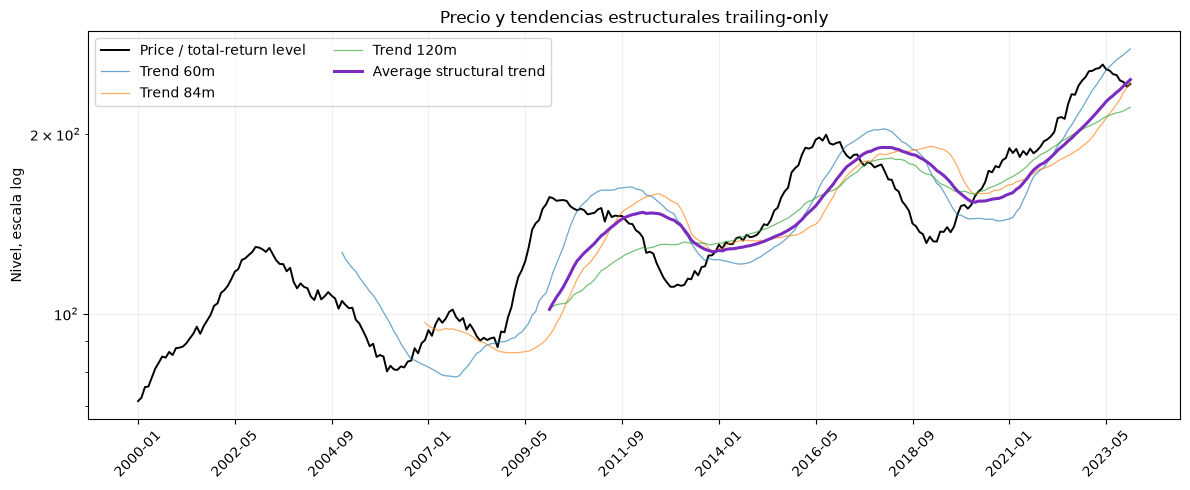

In [4]:
if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(bundle['dates'], bundle['price'], color='black', lw=1.4, label='Price / total-return level')
    for window, values in trend_tracks.items():
        ax.plot(bundle['dates'], np.exp(values), lw=0.9, alpha=0.65, label=f'Trend {window}m')
    ax.plot(bundle['dates'], average_trend_level, color='#7b2cbf', lw=2.2, label='Average structural trend')
    ax.set_yscale('log'); ax.set_title('Precio y tendencias estructurales trailing-only')
    ax.set_ylabel('Nivel, escala log'); ax.legend(ncol=2); ax.grid(alpha=.2)
    step = max(1, len(bundle['dates']) // 10); ax.set_xticks(bundle['dates'][::step]); ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()
else:
    print('Chart skipped: install the notebooks dependency group for Matplotlib.')


## Herramienta 2 — Tendencia estructural promedio

La tendencia promedio reduce dependencia de una única ventana:

$$AverageTrend_t = \exp\left(\frac{1}{|W_t|}\sum_{w\in W_t} Trend_t^{(w)}\right)$$

$W_t$ contiene sólo ventanas con historia suficiente. Además medimos dispersión entre estimaciones. Mucha dispersión significa **incertidumbre de especificación**, no una oportunidad automática. Antes de comparar instrumentos deben congelarse ventanas, escala, deflactor y tratamiento de dividendos. En Cycle 1, la feature preregistrada usa una tendencia Theil–Sen real de 60 meses; este conjunto multi-ventana es un diagnóstico complementario.

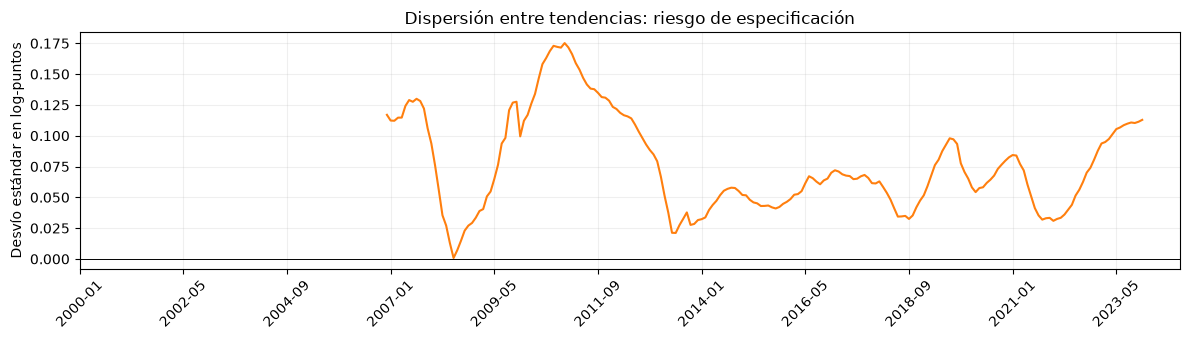

In [5]:
trend_matrix = np.vstack([trend_tracks[w] for w in TREND_WINDOWS])
trend_dispersion = np.full(len(log_price), np.nan)
for i in range(len(log_price)):
    finite = trend_matrix[:, i][np.isfinite(trend_matrix[:, i])]
    if len(finite) >= 2:
        trend_dispersion[i] = np.std(finite, ddof=1)
if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(bundle['dates'], trend_dispersion, color='#ff7f0e')
    ax.set_title('Dispersión entre tendencias: riesgo de especificación')
    ax.set_ylabel('Desvío estándar en log-puntos'); ax.axhline(0, color='black', lw=.7); ax.grid(alpha=.2)
    step = max(1, len(bundle['dates']) // 10); ax.set_xticks(bundle['dates'][::step]); ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()
else:
    print({'latestTrendDispersion': float(trend_dispersion[np.isfinite(trend_dispersion)][-1])})


## Herramienta 3 — Desviación del precio respecto de la tendencia

La magnitud solicitada es:

$$Deviation_t = \log(P_t)-Trend_t$$

Aquí `Trend_t` es la tendencia logarítmica promedio. $Deviation_t>0$ indica precio por encima del nivel estructural estimado y $Deviation_t<0$ por debajo. También mostramos un z-score trailing-only:

$$z_t=\frac{Deviation_t-Median(Deviation_{\le t})}{1.4826\,MAD(Deviation_{\le t})}$$

No equivale a sobre/subvaluación intrínseca: puede reflejar cambios genuinos de fundamentals o una tendencia mal especificada. No deben usarse media y escala de toda la muestra para decisiones históricas.

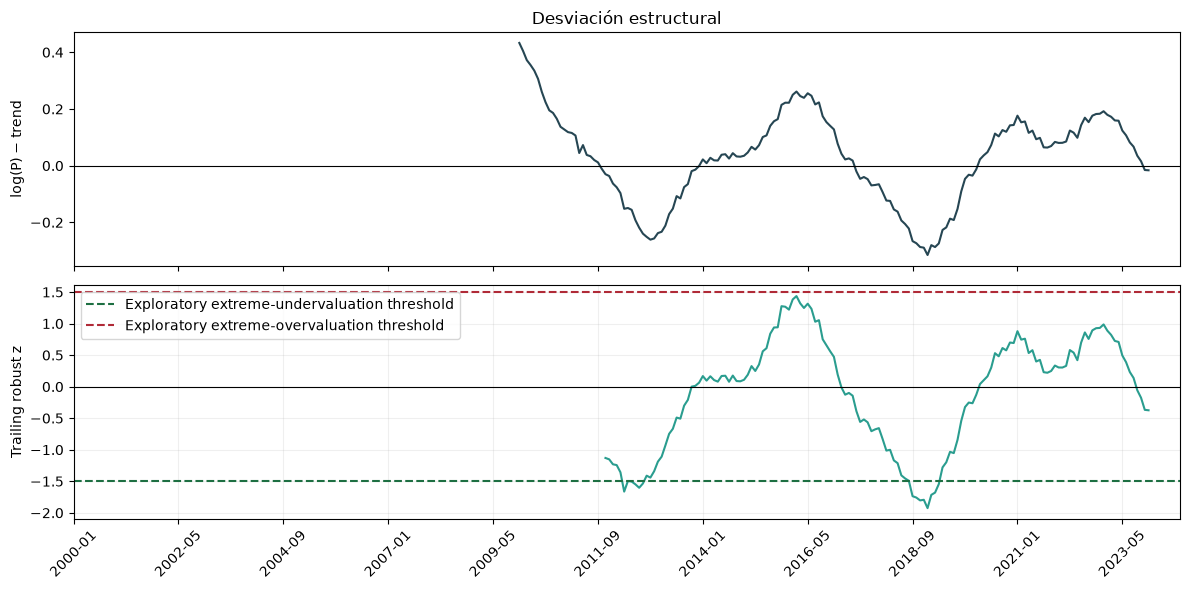

{'latestMonth': np.str_('2023-12'), 'latestDeviation': -0.016276026847330982, 'latestTrailingZ': -0.374509905378816}


In [6]:
deviation = log_price - average_log_trend
deviation_z = np.full(len(deviation), np.nan)
for i in range(len(deviation)):
    history = deviation[:i+1]
    history = history[np.isfinite(history)]
    if len(history) >= 24:
        center = np.median(history); scale = max(1e-9, 1.4826*np.median(np.abs(history-center)))
        deviation_z[i] = (deviation[i]-center)/scale
if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(bundle['dates'], deviation, color='#264653'); axes[0].axhline(0, color='black', lw=.8)
    axes[0].set_ylabel('log(P) − trend'); axes[0].set_title('Desviación estructural')
    axes[1].plot(bundle['dates'], deviation_z, color='#2a9d8f'); axes[1].axhline(0, color='black', lw=.8)
    axes[1].axhline(-1.5, color='#1d6f42', ls='--', label='Exploratory extreme-undervaluation threshold')
    axes[1].axhline(1.5, color='#b02a37', ls='--', label='Exploratory extreme-overvaluation threshold')
    axes[1].set_ylabel('Trailing robust z'); axes[1].legend(); axes[1].grid(alpha=.2)
    step = max(1, len(bundle['dates']) // 10); axes[1].set_xticks(bundle['dates'][::step]); axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()
print({'latestMonth': bundle['dates'][-1], 'latestDeviation': float(deviation[-1]),
       'latestTrailingZ': float(deviation_z[-1])})


## Herramienta 4 — Valuación y expectativas incorporadas

La pregunta es: **¿cuánto de que la economía esté bien ya está incorporado en el precio?** Una descomposición conceptual es:

$$Price_t = E_t(Fundamentals_{t+n}) + SentimentPremium_t$$

En espacio logarítmico usamos el proxy auditable:

$$SentimentPremium_t^{proxy}=\log(P_t)-\log(EFundamentals_t^{proxy})$$

Esto no identifica causalmente sentimiento. Requiere que precio y proxy fundamental sean positivos, comparables y congelados antes de mirar resultados. En datos sintéticos conocemos el fundamental generado. Como Cycle 1 no contiene un nivel de ganancias esperadas, el camino real usa la tendencia estructural como proxy y lo etiqueta como tal; para análisis económico serio debería reemplazarse por earnings/cash-flow point-in-time calificados.

{'fundamentalProxy': 'known synthetic fundamental', 'decompositionEngine': 'reusable-tool', 'warning': 'Proxy decomposition; not an identified market expectation'}


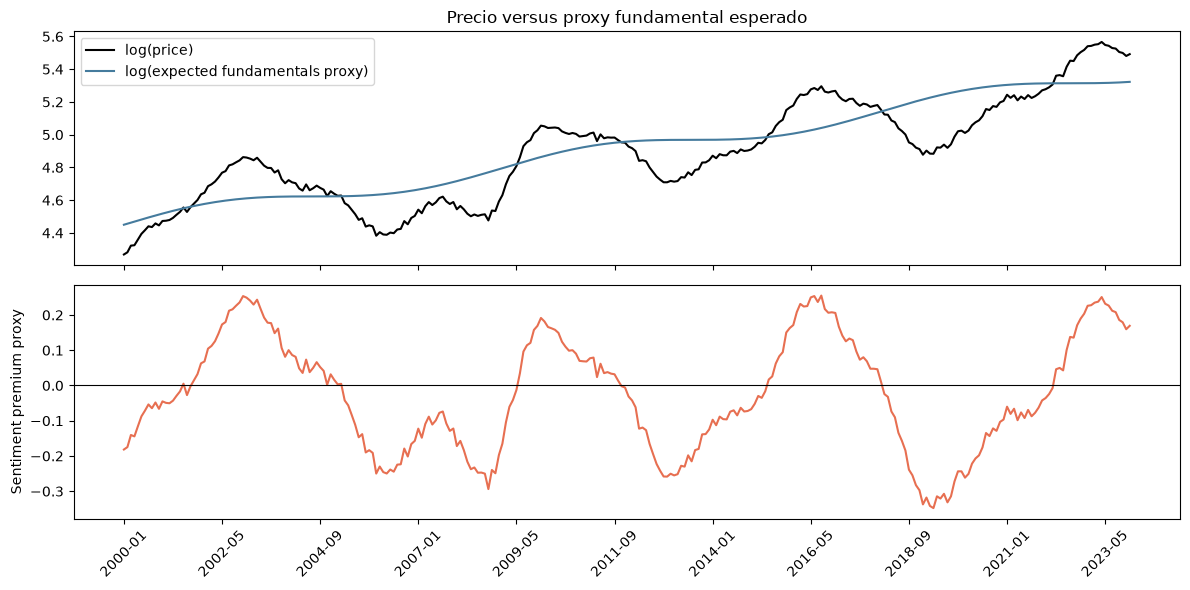

In [7]:
fundamental_proxy = bundle['fundamental_proxy']
fundamental_proxy_kind = 'known synthetic fundamental'
if fundamental_proxy is None:
    fundamental_proxy = average_trend_level.copy()
    fundamental_proxy_kind = 'structural-trend proxy; no Cycle 1 forward-fundamental level available'
sentiment_premium_proxy, decomposition_engine = expectations_decomposition_adapter(bundle['price'], fundamental_proxy)
valid_premium = np.isfinite(sentiment_premium_proxy)
print({'fundamentalProxy': fundamental_proxy_kind, 'decompositionEngine': decomposition_engine,
       'warning': 'Proxy decomposition; not an identified market expectation'})
if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(bundle['dates'], np.log(bundle['price']), label='log(price)', color='black')
    axes[0].plot(bundle['dates'], np.log(fundamental_proxy), label='log(expected fundamentals proxy)', color='#457b9d')
    axes[0].legend(); axes[0].set_title('Precio versus proxy fundamental esperado')
    axes[1].plot(bundle['dates'], sentiment_premium_proxy, color='#e76f51')
    axes[1].axhline(0, color='black', lw=.8); axes[1].set_ylabel('Sentiment premium proxy')
    step = max(1, len(bundle['dates']) // 10); axes[1].set_xticks(bundle['dates'][::step]); axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()


## Herramienta 5 — Resultados reales versus expectativas embebidas

La relación conceptual es:

$$Surprise_t=ActualResults_t-EmbeddedExpectations_t$$

Incluso resultados excelentes pueden coincidir con una caída cuando $ActualResults<EmbeddedExpectations$. Para que la resta tenga sentido ambos términos deben compartir unidad, horizonte y fecha de disponibilidad. Abajo construimos una demostración de crecimiento a 12 meses: crecimiento fundamental realizado versus una expectativa proxy formada con tendencia trailing y prima. Los últimos 12 meses quedan `NaN` porque el resultado futuro todavía no existe en la muestra. **Esta celda es explicativa y no forma parte de los diez candidatos congelados.**

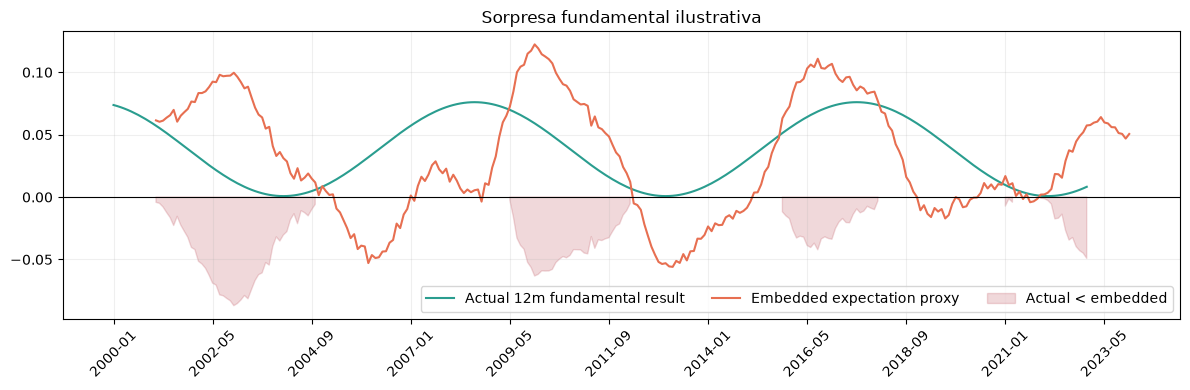

{'comparableUnit': '12-month log growth', 'proxyCoefficient': 0.25, 'negativeSurprises': 127, 'latestObservableSurprise': -0.04913769718862515}


In [8]:
horizon = 12
actual_results = np.full(len(log_price), np.nan)
actual_results[:-horizon] = np.log(fundamental_proxy[horizon:] / fundamental_proxy[:-horizon])
trailing_fund_growth = np.full(len(log_price), np.nan)
trailing_fund_growth[horizon:] = np.log(fundamental_proxy[horizon:] / fundamental_proxy[:-horizon])
embedded_expectations = trailing_fund_growth + 0.25*sentiment_premium_proxy
surprise = actual_results - embedded_expectations
surprise_outcomes = surprise_adapter(actual_results, embedded_expectations)
if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(bundle['dates'], actual_results, label='Actual 12m fundamental result', color='#2a9d8f')
    ax.plot(bundle['dates'], embedded_expectations, label='Embedded expectation proxy', color='#e76f51')
    ax.fill_between(np.arange(len(surprise)), 0, surprise, where=surprise < 0, color='#b02a37', alpha=.18, label='Actual < embedded')
    ax.axhline(0, color='black', lw=.8); ax.set_title('Sorpresa fundamental ilustrativa')
    ax.legend(ncol=3); ax.grid(alpha=.2)
    step = max(1, len(bundle['dates']) // 10); ax.set_xticks(np.arange(len(bundle['dates']))[::step], bundle['dates'][::step], rotation=45)
    plt.tight_layout(); plt.show()
print({'comparableUnit': '12-month log growth', 'proxyCoefficient': 0.25,
       'negativeSurprises': int(np.sum(surprise_outcomes == 'NEGATIVE_SURPRISE')),
       'latestObservableSurprise': float(surprise[np.isfinite(surprise)][-1])})


## Herramienta 6 — ¿Dónde aparece la ganancia extraordinaria?

La hipótesis cualitativa contrasta `FairValue → SlightlyOvervalued` con `ExtremeUndervaluation → Normalization`. Para auditarla necesitamos una definición ex ante. Esta demostración fija `deviation_z <= -1.5` como inicio y el primer cruce posterior de cero como normalización; episodios solapados no se cuentan dos veces. El retorno es logarítmico y no ajusta por riesgo, cash, costos ni sesgo de selección. El umbral es **exploratorio**, no altera el umbral de drawdown ni los estados preregistrados de Cycle 1.

In [9]:
episodes = []
i = 0
while i < len(deviation_z):
    if np.isfinite(deviation_z[i]) and deviation_z[i] <= -1.5:
        end = next((j for j in range(i+1, len(deviation_z)) if np.isfinite(deviation_z[j]) and deviation_z[j] >= 0), None)
        if end is None:
            episodes.append({'start': str(bundle['dates'][i]), 'end': None, 'months': None, 'logReturn': None})
            break
        episodes.append({'start': str(bundle['dates'][i]), 'end': str(bundle['dates'][end]),
                         'months': end-i, 'logReturn': float(log_price[end]-log_price[i])})
        i = end + 1
    else:
        i += 1
print(json.dumps(episodes, indent=2, ensure_ascii=False))
completed = [row for row in episodes if row['logReturn'] is not None]
print({'completedEpisodes': len(completed),
       'medianLogReturn': float(np.median([row['logReturn'] for row in completed])) if completed else None,
       'warning': 'Descriptive in-sample episodes; no causal or prospective claim'})


[
  {
    "start": "2012-04",
    "end": "2013-10",
    "months": 18,
    "logReturn": -0.010250956749717766
  },
  {
    "start": "2018-09",
    "end": "2020-03",
    "months": 18,
    "logReturn": 0.10484127282577305
  }
]
{'completedEpisodes': 2, 'medianLogReturn': 0.04729515803802764, 'warning': 'Descriptive in-sample episodes; no causal or prospective claim'}


## Checklist de lectura manual / Manual review

1. Confirmar `source`, `evidenceTier`, manifiesto y motor de tendencia impresos.
2. Preguntar si las conclusiones sobreviven a ventanas razonables y observar la dispersión, sin elegir retrospectivamente la ventana más atractiva.
3. Separar desviación de tendencia, valuación fundamental y sentimiento: son proxies relacionados, no sinónimos.
4. Para expectativas, congelar proxy, unidad y horizonte antes de observar `ActualResults`.
5. Tratar episodios incompletos, costos, cash y drawdowns explícitamente antes de cualquier evaluación de política.
6. No promover una herramienta exploratoria por un gráfico convincente; requiere preregistración nueva y validación fuera de muestra.

**No investment advice / No es asesoramiento financiero.**

## Workbench · Mediciones validadas y evaluación / Validated inputs and assessment

El panel puede cargar un manifiesto local con mediciones, unidades, instrumento, fuentes y fechas de disponibilidad. Verifica el esquema y SHA-256 del archivo antes de calcular los scores. Una revisión retirada queda faltante; no reaparece su valor anterior.

**El ejemplo incluido sigue siendo sintético.** Cambiar el ticker no descarga datos. Para analizar otras mediciones, seleccione su manifiesto y directorio explícitamente. La validación prueba integridad y coherencia de inputs, no autenticidad independiente de la fuente ni probabilidad de éxito. Las transformaciones y umbrales siguen siendo ilustrativos, no fórmulas propietarias verificadas.

Las series educativas anteriores permanecen sintéticas y separadas de este panel. No hay fallback automático cuando un manifiesto es inválido.


In [ ]:
from spy_predictor_quant.cycle_workbench import (
    SCENARIOS, COMPONENTS, assess, synthetic_fixture, render_html, export_report,
)
from spy_predictor_quant.cycle_workbench_inputs import load_workbench_inputs
from IPython.display import HTML, display

WORKBENCH_INPUT_MODE = 'manifest'  # 'manifest' or 'fixture'; never auto-fallback.
# Current verified macro snapshot; earlier educational charts stay synthetic.
WORKBENCH_INPUT_ROOT = REPO_ROOT / 'datasets' / 'workbench' / 'current-20260909-macro'
WORKBENCH_MANIFEST = WORKBENCH_INPUT_ROOT / 'SPY-manifest.json'  # QQQ-manifest.json is also available.
WORKBENCH_AS_OF = json.loads((WORKBENCH_INPUT_ROOT / 'verification.json').read_text())['as_of']
WORKBENCH_SCENARIO = 'cheap-deteriorating'  # Used only in fixture mode.
WORKBENCH_SYMBOL = None  # Manifest identity by default; an override must match.
EXPORT_WORKBENCH = False
WORKBENCH_OUTPUT = REPO_ROOT / 'reports' / 'cycle-workbench' / 'notebooks'

input_audit = None
if WORKBENCH_INPUT_MODE == 'manifest':
    validated_inputs = load_workbench_inputs(WORKBENCH_MANIFEST,
        as_of=WORKBENCH_AS_OF, allowed_root=WORKBENCH_INPUT_ROOT)
    symbol = validated_inputs.metadata['symbol']
    if WORKBENCH_SYMBOL is not None and WORKBENCH_SYMBOL != symbol:
        raise ValueError('Symbol override does not match the manifest instrument.')
    workbench_report = assess(validated_inputs.observations, as_of=WORKBENCH_AS_OF,
        symbol=symbol, input_metadata=validated_inputs.metadata)
    input_audit = validated_inputs.audit
    print('Input validation:', validated_inputs.metadata['validation_scope'])
    print('Evidence tier:', validated_inputs.metadata['evidence_tier'])
    print('Input-file audit:', input_audit)
elif WORKBENCH_INPUT_MODE == 'fixture':
    workbench_report = assess(synthetic_fixture(WORKBENCH_SCENARIO),
        as_of=WORKBENCH_AS_OF, symbol=WORKBENCH_SYMBOL or 'DEMO')
else:
    raise ValueError('Choose manifest or fixture explicitly.')
display(HTML(render_html(workbench_report)))
if EXPORT_WORKBENCH:
    print(export_report(workbench_report, WORKBENCH_OUTPUT, input_audit=input_audit))


In [ ]:
# Selected input panel: derived scores, not the separate scenario comparison.
if HAS_MATPLOTLIB:
    selected = workbench_report['components']
    labels = list(COMPONENTS)
    values = [selected[key]['score'] if selected[key]['status'] == 'FRESH' else np.nan for key in labels]
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.bar(labels, np.nan_to_num(values), color=['#c45a50' if key == 'stress' else '#4c78a8' for key in labels])
    ax.axhline(0, color='gray', linewidth=.7)
    ax.set_ylim(-1.15, 1.15)
    ax.set_title(f"{workbench_report['symbol']} · {workbench_report['instrument']['action']} · {', '.join(workbench_report['evidence_tiers'])}")
    for i, (key, value) in enumerate(zip(labels, values)):
        ax.text(i, 0 if np.isnan(value) else value, selected[key]['status'] if np.isnan(value) else f'{value:.2f}', ha='center', va='bottom')
    ax.set_ylabel('Illustrative score; stress higher = more risk')
    plt.tight_layout()
    plt.show()


### Comparar escenarios / Compare scenarios

El panel muestra cómo cambia el análisis al cambiar los componentes. Un activo aparentemente barato puede exigir esperar si el precio sigue deteriorándose. Calidad y valuación son inputs sintéticos explícitos: no se infieren de una caída de precio. La cobertura mide datos disponibles, no probabilidad de éxito.


In [ ]:
scenario_reports = [assess(synthetic_fixture(case), as_of=WORKBENCH_AS_OF,
                           symbol=f'DEMO:{case}') for case in SCENARIOS]
for case, report in zip(SCENARIOS, scenario_reports):
    print(f"{case:22s} market={report['market']['posture']:22s} instrument={report['instrument']['action']}")
if HAS_MATPLOTLIB:
    matrix = np.array([[report['components'][key]['score']
                        if report['components'][key]['status'] == 'FRESH' else np.nan
                        for key in COMPONENTS] for report in scenario_reports], dtype=float)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    heat = ax.imshow(np.ma.masked_invalid(matrix), cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(COMPONENTS)), COMPONENTS)
    ax.set_yticks(range(len(SCENARIOS)), SCENARIOS)
    ax.set_title('Handcrafted component scores · stress higher = more risk; others higher = supportive')
    for row in range(len(SCENARIOS)):
        for col in range(len(COMPONENTS)):
            value = matrix[row, col]
            ax.text(col, row, 'missing' if np.isnan(value) else f'{value:.1f}', ha='center', va='center')
    fig.colorbar(heat, ax=ax, label='Illustrative score (not probability)')
    plt.tight_layout()
    plt.show()
